# HOUSE PRICES - ADVANCED REGRESSION TECHNIQUES

## Data Understanding
Phần này thực hiện khám phá và tìm hiểu dữ liệu (EDA), bao gồm kiểm tra cấu trúc dữ liệu, kiểu dữ liệu, dữ liệu thiếu, phân phối của biến mục tiêu SalePrice và mối tương quan giữa các đặc trưng.

In [4]:
# CELL 1: IMPORT THƯ VIỆN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Import thư viện thành công!")

Import thư viện thành công!


In [1]:
# khởi tạo thư viện xgboost
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 8.7 MB/s eta 0:00:06
   ---- ----------------------------------- 5.5/48.9 MB 18.9 MB/s eta 0:00:03
   ---------- ----------------------------- 13.4/48.9 MB 26.5 MB/s eta 0:00:02
   ----------------- ---------------------- 21.2/48.9 MB 29.6 MB/s eta 0:00:01
   ----------------------- ---------------- 29.4/48.9 MB 31.4 MB/s eta 0:00:01
   ------------------------------ --------- 37.2/48.9 MB 32.3 MB/s eta 0:00:01
   ------------------------------------ --- 44.6/48.9 MB 32.8 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 31.8 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 30.1 MB/s  0:00:01


In [5]:
# CELL 2: LOAD DATA

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (1460, 81)
Test Shape: (1459, 80)


In [6]:
# CELL 3: KIỂM TRA THÔNG TIN TẬP TRAIN

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
# CELL 4: KIỂM TRA THÔNG TIN TẬP TEST

test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [8]:
# CELL 5: KIỂM TRA GIÁ TRỊ THIẾU TRONG TRAIN

train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

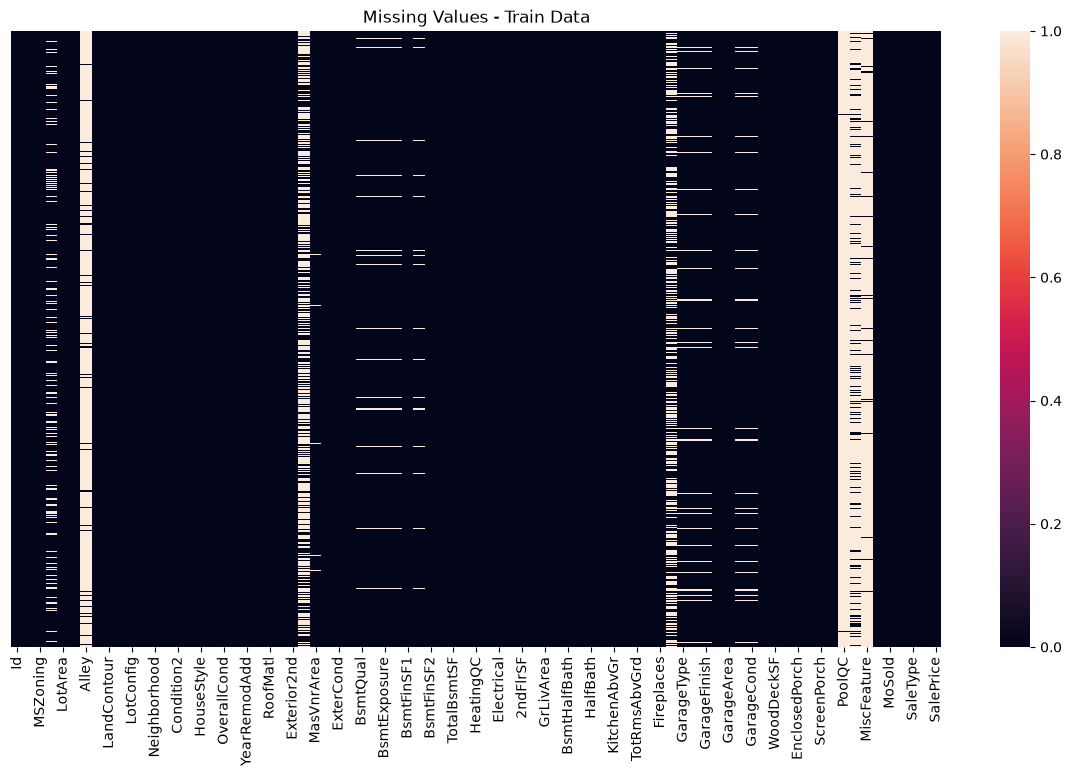

In [9]:
# CELL 6: HEATMAP GIÁ TRỊ THIẾU CỦA TRAIN

plt.figure(figsize=(15, 8))
sns.heatmap(train.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Train Data")
plt.show()

In [10]:
# CELL 7: KIỂM TRA GIÁ TRỊ THIẾU TRONG TEST

test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

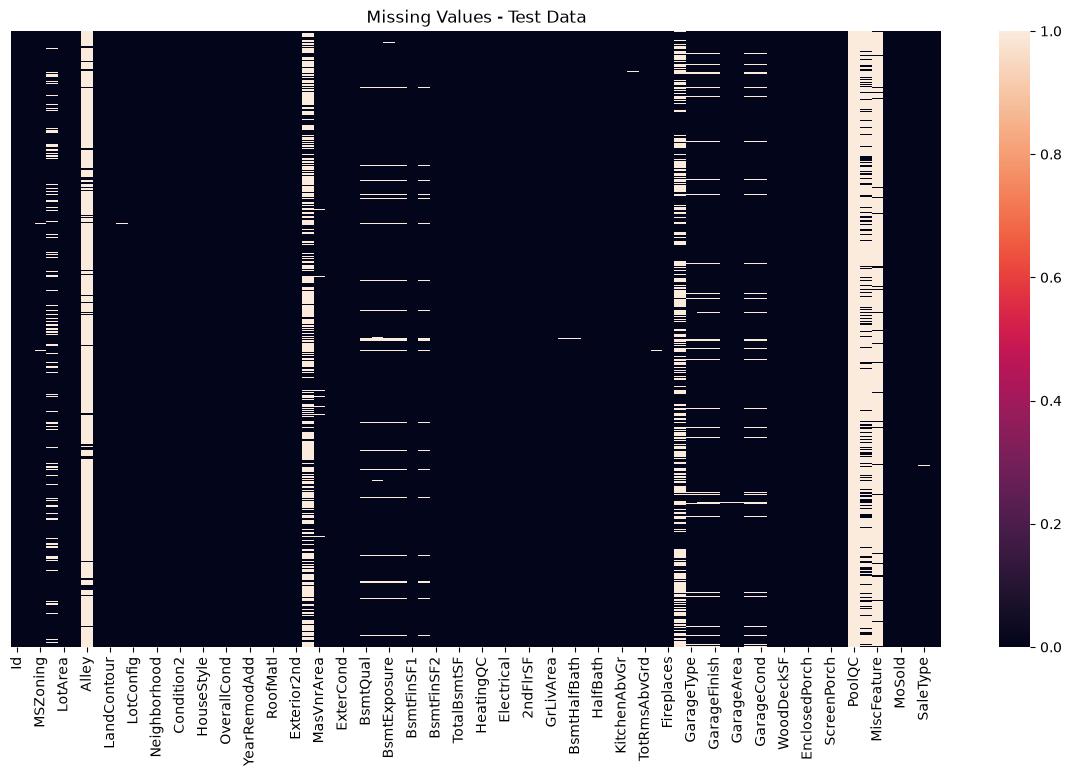

In [11]:
# CELL 8: HEATMAP GIÁ TRỊ THIẾU CỦA TEST

plt.figure(figsize=(15, 8))
sns.heatmap(test.isnull(), yticklabels=False, cbar=True)

plt.title("Missing Values - Test Data")
plt.show()

Biểu đồ phân phối giá nhà

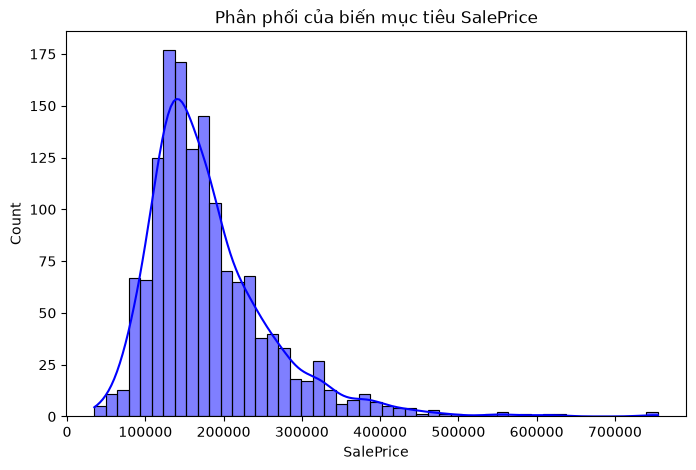

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title("Phân phối của biến mục tiêu SalePrice")
plt.show()

In [13]:
# CELL 9: XỬ LÝ MISSING VALUES CHO TRAIN VÀ TEST (THEO FILE PDF MẪU)
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                 'GarageQual', 'GarageCond']
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])
for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 
                'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 
                 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])
for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

# Loại bỏ các cột khuyết > 70% và cột Id
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)

print("Đã xử lý sạch missing values.")
print("Train Shape:", train.shape) 
print("Test Shape:", test.shape)   

Đã xử lý sạch missing values.
Train Shape: (1460, 76)
Test Shape: (1459, 75)


In [14]:
# CELL 10: ONE-HOT ENCODING (THEO FILE PDF MẪU)
final_df = pd.concat([train, test], axis=0)

all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
               'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
               'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
               'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
               'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
               'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

def cat_onehot_encoding(multicol):
    df_final = final_df.copy()
    i = 0
    for fields in multicol:
        df1 = pd.get_dummies(final_df[fields], drop_first=True)
        final_df.drop([fields], axis=1, inplace=True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)
        i = i + 1
    df_final = pd.concat([final_df, df_final], axis=1)
    return df_final

final_df = cat_onehot_encoding(all_cat_col)
# Lọc bỏ các cột trùng tên
final_df = final_df.loc[:, ~final_df.columns.duplicated()]
print("Kích thước sau khi mã hóa và lọc trùng:", final_df.shape) 

Kích thước sau khi mã hóa và lọc trùng: (2919, 176)


In [15]:
# CELL 11: TÁCH LẠI TẬP TRAIN & TEST BÀN GIAO CHO MODEL
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]

# Bỏ SalePrice ở tập test
df_test.drop(['SalePrice'], axis=1, inplace=True)

# Tách ma trận đặc trưng x_train và nhãn y_train
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

print("Train Features Shape (x_train):", x_train.shape) 
print("Train Target Shape (y_train):", y_train.shape)  
print("Test Features Shape (df_test):", df_test.shape) 

Train Features Shape (x_train): (1460, 175)
Train Target Shape (y_train): (1460,)
Test Features Shape (df_test): (1459, 175)


In [16]:
# CELL 12: IMPORT THƯ VIỆN BỔ SUNG CHO MODELING

import warnings
import pickle
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb

warnings.filterwarnings('ignore')
print("Import thư viện Modeling thành công!")

Import thư viện Modeling thành công!


In [17]:
# CELL 13: XÂY DỰNG MÔ HÌNH BASELINE - DECISION TREE

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(x_train, y_train)

print("Huấn luyện Decision Tree thành công!")
print("Độ sâu cây:", dt_model.get_depth())
print("Số lá cây:", dt_model.get_n_leaves())

Huấn luyện Decision Tree thành công!
Độ sâu cây: 30
Số lá cây: 1397


In [18]:
# CELL 14: ĐÁNH GIÁ DECISION TREE

pred_dt_train = dt_model.predict(x_train)
dt_train_rmse = np.sqrt(mean_squared_error(y_train, pred_dt_train))

dt_cv_scores = cross_val_score(dt_model, x_train, y_train,
                               cv=5, scoring='neg_root_mean_squared_error')
dt_cv_rmse = -dt_cv_scores.mean()

print("Decision Tree - Train RMSE:", round(dt_train_rmse, 2))
print("Decision Tree - CV RMSE (5-fold):", round(dt_cv_rmse, 2))

Decision Tree - Train RMSE: 153.6
Decision Tree - CV RMSE (5-fold): 41937.01


In [19]:
# CELL 15: DỰ ĐOÁN VÀ LƯU KẾT QUẢ DECISION TREE

pred_dt = dt_model.predict(df_test)
print("Predictions shape:", pred_dt.shape)

sub_dt = pd.read_csv('sample_submission.csv')
sub_dt['SalePrice'] = pred_dt
sub_dt.to_csv('submission_decision_tree.csv', index=False)
print("Đã lưu file: submission_decision_tree.csv")

Predictions shape: (1459,)
Đã lưu file: submission_decision_tree.csv


In [20]:
# CELL 16: XÂY DỰNG MÔ HÌNH XGBOOST

xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(x_train, y_train)

print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)


In [21]:
# CELL 17: TINH CHỈNH SIÊU THAM SỐ BẰNG RANDOMIZEDSEARCHCV

param = {
    'n_estimators'    : [100, 500, 900, 1100, 1500],
    'max_depth'       : [2, 3, 5, 10, 15],
    'learning_rate'   : [0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 2, 3, 4],
    'booster'         : ['gbtree', 'gblinear'],
    'base_score'      : [0.25, 0.5, 0.75, 1]
}

random_cv = RandomizedSearchCV(
    estimator           = xgb_model,
    param_distributions = param,
    cv                  = 5,
    n_iter              = 50,
    scoring             = 'neg_mean_absolute_error',
    n_jobs              = 4,
    verbose             = 5,
    return_train_score  = True,
    random_state        = 42
)
random_cv.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'base_score': [0.25, 0.5, ...], 'booster': ['gbtree', 'gblinear'], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the p

In [22]:
# CELL 18: KẾT QUẢ TÌM KIẾM THAM SỐ TỐT NHẤT

random_cv.best_estimator_

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",1
,booster,'gbtree'
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [23]:
# CELL 19: HUẤN LUYỆN LẠI VỚI THAM SỐ TỐT NHẤT

xgb_model = xgb.XGBRegressor(
    base_score         = random_cv.best_params_['base_score'],
    booster            = random_cv.best_params_['booster'],
    learning_rate      = random_cv.best_params_['learning_rate'],
    max_depth          = random_cv.best_params_['max_depth'],
    min_child_weight   = random_cv.best_params_['min_child_weight'],
    n_estimators       = random_cv.best_params_['n_estimators'],
    random_state       = 0
)
xgb_model.fit(x_train, y_train)

print(xgb_model)

XGBRegressor(base_score=1, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=4, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1100,
             n_jobs=None, num_parallel_tree=None, ...)


In [24]:
# CELL 20: LƯU MÔ HÌNH VÀ DỰ ĐOÁN

f = 'xgb_model.pkl'
pickle.dump(xgb_model, open(f, 'wb'))

pred_xgb = xgb_model.predict(df_test)
print(pred_xgb.shape)

(1459,)


In [25]:
# CELL 21: LƯU KẾT QUẢ DỰ ĐOÁN XGBOOST

sub_xgb = pd.read_csv('sample_submission.csv')
sub_xgb['SalePrice'] = pred_xgb
sub_xgb.to_csv('submission_xgboost.csv', index=False)
print("Đã lưu file: submission_xgboost.csv")

Đã lưu file: submission_xgboost.csv
